In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

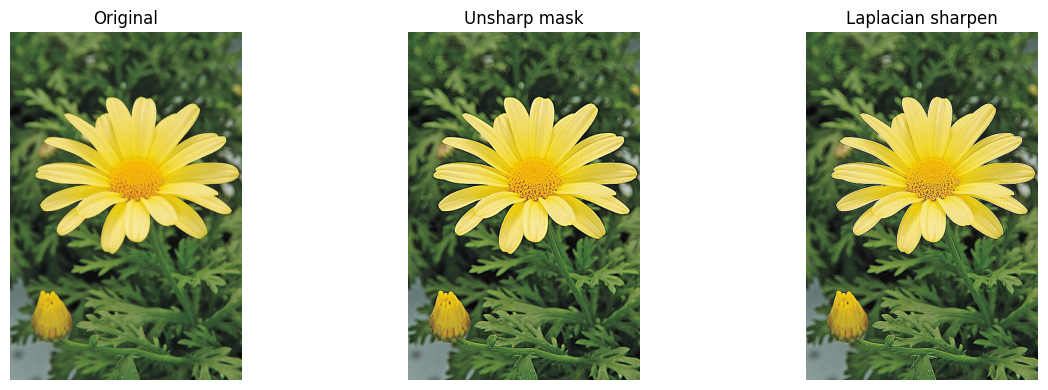

In [2]:
def unsharp_mask(
    bgr: np.ndarray,
    sigma: float = 1.5,
    amount: float = 1.2,
    ksize: int = 0,
) -> np.ndarray:
    """Unsharp mask in float32; returns uint8 BGR."""
    blur = cv2.GaussianBlur(bgr, (ksize, ksize) if ksize > 0 else (0, 0), sigma)
    f = bgr.astype(np.float32)
    detail = f - blur.astype(np.float32)
    out = f + amount * detail
    return np.clip(np.round(out), 0, 255).astype(np.uint8)


def laplacian_sharpen(bgr: np.ndarray, beta: float = 0.3) -> np.ndarray:
    """I_sharp = I - beta * Laplacian(I) on each channel (simple discrete Laplacian)."""
    f = bgr.astype(np.float32)
    out = np.zeros_like(f)
    for c in range(3):
        lap = cv2.Laplacian(f[:, :, c], cv2.CV_32F, ksize=3)
        out[:, :, c] = f[:, :, c] - beta * lap
    return np.clip(np.round(out), 0, 255).astype(np.uint8)


path = "images/daisy.jpg"
bgr = cv2.imread(path)
if bgr is None:
    raise FileNotFoundError(path)

sharp_um = unsharp_mask(bgr, sigma=2.0, amount=1.25, ksize=0)
sharp_lap = laplacian_sharpen(bgr, beta=0.35)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_um = cv2.cvtColor(sharp_um, cv2.COLOR_BGR2RGB)
rgb_lap = cv2.cvtColor(sharp_lap, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(rgb)
axes[0].set_title("Original")
axes[1].imshow(rgb_um)
axes[1].set_title("Unsharp mask")
axes[2].imshow(rgb_lap)
axes[2].set_title("Laplacian sharpen")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()